In [1]:
import pandas as pd
import os

SILVER_DIR = r"D:\DSS_CK\financial-fraud-dss\data\2_silver"

# Định nghĩa lại đường dẫn thực tế của bạn
paths = {
    'users': os.path.join(SILVER_DIR, 'users_cleaned.parquet'),
    'cards': os.path.join(SILVER_DIR, 'cards_cleaned.parquet'), # Kiểm tra xem là card_cleaned hay cards_cleaned
    'transactions': os.path.join(SILVER_DIR, 'transactions_cleaned_part_1.parquet'),
    'labels': os.path.join(SILVER_DIR, 'labels_cleaned.parquet'),
    'mcc': os.path.join(SILVER_DIR, 'mcc_cleaned.parquet')
}

print("=== KIỂM TRA CẤU TRÚC FILE PARQUET ===")
for name, path in paths.items():
    if os.path.exists(path):
        # Chỉ đọc 5 dòng đầu để xem cấu trúc cột cho nhẹ RAM
        df_temp = pd.read_parquet(path, engine='pyarrow').head(5)
        print(f"\n📌 FILE: {name.upper()} ({path})")
        print(f" -> Các cột: {list(df_temp.columns)}")
        print(f" -> Kiểu dữ liệu một số cột chính:\n{df_temp.dtypes.head(5)}")
    else:
        print(f"\n❌ Không tìm thấy file: {path}")

=== KIỂM TRA CẤU TRÚC FILE PARQUET ===

📌 FILE: USERS (D:\DSS_CK\financial-fraud-dss\data\2_silver\users_cleaned.parquet)
 -> Các cột: ['user_id', 'user_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'address', 'latitude', 'longitude', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards']
 -> Kiểu dữ liệu một số cột chính:
user_id           int64
user_age          int64
retirement_age    int64
birth_year        int64
birth_month       int64
dtype: object

📌 FILE: CARDS (D:\DSS_CK\financial-fraud-dss\data\2_silver\cards_cleaned.parquet)
 -> Các cột: ['card_id', 'user_id', 'card_brand', 'card_type', 'card_number', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web']
 -> Kiểu dữ liệu một số cột chính:
card_id        int64
user_id        int64
card_brand       str
card_type        str
card_number    int64
dtype: object

📌 FILE: TRANSACTIONS (D:\DSS_CK\financial-frau

In [10]:
import pandas as pd
import numpy as np
import os
import gc
import glob
from datetime import datetime

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN TỚI TẦNG SILVER
# ==========================================
# Thay đổi đường dẫn này trỏ tới thư mục 2_silver của dự án
SILVER_DIR = r"D:\DSS_CK\financial-fraud-dss\data\2_silver"
OUTPUT_FILE = r"D:\DSS_CK\financial-fraud-dss\data\featured_transactions_data1.csv" # Hoặc lưu ở đâu tùy bạn

FAST_TRAIN_MODE = True  # Bật True để lấy mẫu nén RAM (Chống sập máy)
DOWNSAMPLE_RATIO = 123   # Tỷ lệ 1 gian lận : 123 hợp pháp

# ==========================================
# HÀM TỐI ƯU HOÁ BỘ NHỚ RAM 
# ==========================================
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and not isinstance(col_type, pd.CategoricalDtype) and not str(col_type).startswith('datetime'):
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)  
            elif str(col_type)[:5] == 'float':
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            # Bảo vệ các cột ID và Date không bị chuyển thành category
            if col.endswith('_id') or col == 'id' or col == 'transaction_id' or 'date' in col:
                df[col] = df[col].astype(str)
            else:
                num_unique = len(df[col].unique())
                if num_unique / len(df) < 0.5:
                    df[col] = df[col].astype('category')
    return df

# ==========================================
# HÀM NẠP TỰ ĐỘNG CÁC KHỐI PARQUET SẠCH
# ==========================================
def load_silver_parquet_data():
    print(f"\n[Bước 1.1] Đang quét và nạp dữ liệu từ: {SILVER_DIR} ...")
    
    # 1. Đọc bảng Users và Cards (Giữ nguyên logic cũ)
    cols_users = [
        'user_id',
        'user_age',
        'yearly_income',
        'total_debt',
        'credit_score',
        'latitude',
        'longitude'
    ]

    df_users = pd.read_parquet(
        os.path.join(SILVER_DIR, 'users_cleaned.parquet'),
        columns=cols_users
    )

    df_users.rename(
        columns={
            'latitude': 'user_lat',
            'longitude': 'user_lon'
        },
        inplace=True
    )

    df_users = reduce_mem_usage(df_users)

    cols_cards = [
        'card_id',
        'user_id',
        'card_type',
        'credit_limit',
        'card_on_dark_web',
        'has_chip',
        'acct_open_date',
        'year_pin_last_changed'
    ]

    df_cards = pd.read_parquet(
        os.path.join(SILVER_DIR, 'cards_cleaned.parquet'),
        columns=cols_cards
    )

    df_cards = reduce_mem_usage(df_cards)

    # 2. Đọc bảng Transactions và phân định Train/Test theo thời gian file
    trans_pattern = os.path.join(
        SILVER_DIR,
        'transactions_cleaned_part_*.parquet'
    )

    trans_files = sorted(glob.glob(trans_pattern))

    print(
        f" -> Tự động phát hiện {len(trans_files)} khối dữ liệu transactions."
    )

    cols_trans = [
        'transaction_id',
        'date',
        'user_id',
        'card_id',
        'amount',
        'use_chip',
        'mcc',
        'errors',
        'merchant_state',
        'merchant_id',
        'is_fraud'
    ]

    temp_check = pd.read_parquet(trans_files[0])

    if 'merch_lat' in temp_check.columns:
        cols_trans.extend(['merch_lat', 'merch_long'])

    # Tính mốc phân chia: 80% số file đầu làm Train, 20% số file cuối làm Test
    n_files = len(trans_files)
    split_file_idx = int(n_files * 0.8)

    chunks = []

    for i, file_path in enumerate(trans_files):
        print(f" + Đang nạp khối {i+1}/{n_files}...")

        chunk = pd.read_parquet(
            file_path,
            columns=cols_trans
        )

        if 'merch_lat' in chunk.columns:
            chunk.rename(
                columns={
                    'merch_lat': 'merchant_lat',
                    'merch_long': 'merchant_lon'
                },
                inplace=True
            )

        # PHÂN CHIA CHIẾN LƯỢC LỌC DỮ LIỆU
        if i < split_file_idx:

            # Các file thuộc tập TRAIN -> Áp dụng Downsample để nhẹ RAM và học nhanh
            if FAST_TRAIN_MODE:
                fraud_chunk = chunk[chunk['is_fraud'] == 1]
                legit_chunk = chunk[chunk['is_fraud'] == 0]

                n_sample = len(fraud_chunk) * DOWNSAMPLE_RATIO

                if len(legit_chunk) > n_sample:
                    legit_chunk = legit_chunk.sample(
                        n=n_sample,
                        random_state=42
                    )

                chunk = pd.concat(
                    [fraud_chunk, legit_chunk],
                    ignore_index=True
                )

            chunk['set_type'] = 'train'

        else:
            # Các file thuộc tập TEST -> GIỮ NGUYÊN 100%
            chunk['set_type'] = 'test'

        chunk = reduce_mem_usage(chunk)

        chunks.append(chunk)

    df_transactions = pd.concat(
        chunks,
        ignore_index=True
    )

    print(
        f" -> Tổng số dòng Transactions nạp vào RAM: "
        f"{len(df_transactions):,}"
    )

    return df_users, df_cards, df_transactions

# ==========================================
# LỚP FEATURE ENGINEERING (CẢI TIẾN)
# ==========================================
# ==========================================
# LỚP FEATURE ENGINEERING (PHIÊN BẢN HOÀN CHỈNH NHẤT)
# Tích hợp: Behavioral Stats + Domain Knowledge
# ==========================================
class RealDataFeatureEngineer:
    def __init__(self, df_users, df_cards, df_transactions):
        self.df_users = df_users
        self.df_cards = df_cards
        self.df_transactions = df_transactions

    def _join_data(self):
        # 1. Nối Transactions với Cards
        df = self.df_transactions.merge(
            self.df_cards, 
            on=['card_id', 'user_id'], 
            how='left'
        )
        del self.df_transactions
        gc.collect()

        # 2. Nối tiếp với Users
        df = df.merge(
            self.df_users, 
            on='user_id', 
            how='left'
        )
        del self.df_users, self.df_cards
        gc.collect()

        return df

    def _haversine_distance(self, lat1, lon1, lat2, lon2):
        R = 6371
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return (R * c).astype(np.float32)

    def build_features(self):
        print("\n[Bước 2.1] Đang khớp nối dữ liệu thô (Merge & Join)...")
        df = self._join_data()

        print("[Bước 2.2] Đang chuyển đổi định dạng ngày tháng...")
        df['date'] = pd.to_datetime(df['date']) 
        df['is_error_txn'] = df['errors'].notnull().astype(np.int8)

        # --- GIAI ĐOẠN 1: TÍNH TOÁN THEO THẺ VÀ LỊCH SỬ TÍCH LŨY ---
        print("[Bước 2.3] Sắp xếp theo Thẻ & Thời gian để tính Card Features...")
        df = df.sort_values(['card_id', 'date']).reset_index(drop=True)

        df['flag_is_refund'] = (df['amount'] < 0).astype(np.int8)
        df['abs_amount'] = df['amount'].abs().astype(np.float32)
        df['net_amount'] = df['amount'].astype(np.float32)
        df['log_abs_amount'] = np.log1p(df['abs_amount']).astype(np.float32)

        df['time_since_last_txn'] = df.groupby('card_id')['date'].diff().dt.total_seconds().fillna(999999).astype(np.float32)
        df['flag_rapid_sequence'] = (df['time_since_last_txn'] < 60).astype(np.int8)

        # NÂNG CẤP 1: Đếm tích lũy (Cumcount) - Khắc phục lỗi rò rỉ dữ liệu của is_new_merchant
        df['merchant_txn_cumcount'] = df.groupby(['card_id', 'merchant_id']).cumcount().astype(np.int16)
        df['is_new_merchant'] = (df['merchant_txn_cumcount'] == 0).astype(np.int8)
        
        df['mcc_txn_cumcount'] = df.groupby(['card_id', 'mcc']).cumcount().astype(np.int16)
        df['is_first_time_mcc'] = (df['mcc_txn_cumcount'] == 0).astype(np.int8)

        # Tính toán Rolling 1h và 7d cho Card
        df = df.set_index('date')
        df['txn_count_1h'] = df.groupby('card_id')['transaction_id'].rolling('1h', closed='left').count().reset_index(level=0, drop=True).values
        df['txn_count_1h'] = df['txn_count_1h'].fillna(0).astype(np.int16)
        df['flag_burst_1h'] = (df['txn_count_1h'] > 5).astype(np.int8)

        rolling_7d = df.groupby('card_id')['abs_amount'].rolling('7d', closed='left')
        df['amount_mean_7d'] = rolling_7d.mean().reset_index(level=0, drop=True).values.astype(np.float32)
        df['amount_std_7d'] = rolling_7d.std().reset_index(level=0, drop=True).values.astype(np.float32)
        df = df.reset_index()
        gc.collect()

        # --- GIAI ĐOẠN 2: THỐNG KÊ THÓI QUEN THEO DANH MỤC (MCC STATS) ---
        print("[Bước 2.4] Phân tích thói quen số tiền theo từng MCC...")
        df = df.sort_values(['card_id', 'mcc', 'date']).reset_index(drop=True)
        df = df.set_index('date')
        
        # NÂNG CẤP 2: Thói quen tiêu dùng theo MCC
        rolling_mcc_30d = df.groupby(['card_id', 'mcc'])['abs_amount'].rolling('30d', closed='left')
        df['amount_mean_30d_mcc'] = rolling_mcc_30d.mean().reset_index(level=[0,1], drop=True).values.astype(np.float32)
        df['amount_std_30d_mcc'] = rolling_mcc_30d.std().reset_index(level=[0,1], drop=True).values.astype(np.float32)
        df = df.reset_index()

        df['amount_zscore_mcc'] = np.where(df['amount_std_30d_mcc'] > 0, 
                                           (df['abs_amount'] - df['amount_mean_30d_mcc']) / df['amount_std_30d_mcc'], 
                                           0).astype(np.float32)
        df['flag_abnormal_mcc_amount'] = (df['amount_zscore_mcc'] > 3.0).astype(np.int8)
        gc.collect()

        # --- GIAI ĐOẠN 3: TÍNH TOÁN THEO NGƯỜI DÙNG (USER-BASED VELOCITY) ---
        print("[Bước 2.5] Tính toán tần suất rủi ro cấp độ User...")
        df = df.sort_values(['user_id', 'date']).reset_index(drop=True)
        df = df.set_index('date')
        
        # NÂNG CẤP 3: Phát hiện kẻ gian tiêu chéo nhiều thẻ của cùng 1 nạn nhân
        df['user_txn_count_24h'] = df.groupby('user_id')['transaction_id'].rolling('24h', closed='left').count().reset_index(level=0, drop=True).values
        df['user_txn_count_24h'] = df['user_txn_count_24h'].fillna(0).astype(np.int16)
        df = df.reset_index()
        gc.collect()

        # --- GIAI ĐOẠN 4: TÍNH TOÁN NGHIỆP VỤ ĐIỂM BÁN (DOMAIN KNOWLEDGE) ---
        print("[Bước 2.6] Bắt bài nghiệp vụ: Thẻ quà tặng & POS Khống...")
        df['flag_round_amount'] = (df['abs_amount'].isin([1, 5, 10, 20, 50, 100]) & (df['flag_is_refund'] == 0)).astype(np.int8)
        
        # NÂNG CẤP 4: Kịch bản gian lận Siêu thị
        supermarket_mccs = ['5411', '5310', 5411, 5310] 
        # Bắt Gift Card Laundering (Giao dịch siêu thị > 1000)
        df['flag_supermarket_whale'] = (df['mcc'].isin(supermarket_mccs) & (df['abs_amount'] > 1000)).astype(np.int8)

        # Bắt POS Khống / Đáo hạn thẻ
        df['merchant_avg_amount'] = df.groupby('merchant_id')['abs_amount'].transform('mean')
        df['flag_fake_pos_grocery'] = (
            df['mcc'].isin(supermarket_mccs) & 
            (df['merchant_avg_amount'] > 500) & 
            (df['flag_round_amount'] == 1)
        ).astype(np.int8)
        df.drop(columns=['merchant_avg_amount'], inplace=True)

        # Tính Error Count
        df = df.sort_values(['merchant_id', 'date']).reset_index(drop=True)
        df = df.set_index('date') 
        df['merchant_error_count_24h'] = df.groupby('merchant_id')['is_error_txn'].rolling('24h', closed='left').sum().reset_index(level=0, drop=True).values
        df['merchant_error_count_24h'] = df['merchant_error_count_24h'].fillna(0).astype(np.int16)
        df['flag_hot_merchant'] = (df['merchant_error_count_24h'] > 5).astype(np.int8)

        df = df.reset_index()
        df.drop(columns=['is_error_txn'], inplace=True)
        gc.collect()

        # --- GIAI ĐOẠN 5: CÁC LOGIC HOÀN THIỆN CÒN LẠI ---
        print("[Bước 2.7] Hoàn thiện các đặc trưng bảo mật và địa lý...")
        df = df.sort_values(['card_id', 'date']).reset_index(drop=True)

        df['flag_night_txn'] = df['date'].dt.hour.between(0, 5).astype(np.int8)
        df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(np.int8)

        df['amount_zscore'] = np.where(df['amount_std_7d'] > 0, (df['abs_amount'] - df['amount_mean_7d']) / df['amount_std_7d'], 0).astype(np.float32)
        df['flag_amount_spike'] = (df['amount_zscore'] > 3.0).astype(np.int8)

        if 'credit_limit' in df.columns:
            df['flag_near_credit_limit'] = (df['abs_amount'] > (0.85 * df['credit_limit'])).astype(np.int8)
        else:
            df['flag_near_credit_limit'] = np.int8(0)

        df['flag_high_mcc_risk'] = df['mcc'].isin(['4829', '6011', '7995', '5912', '6051', 4829, 6011, 7995, 5912, 6051]).astype(np.int8)
        df['flag_dark_web_card'] = (df['card_on_dark_web'] == 'Yes').astype(np.int8)
        df['flag_chip_bypass'] = ((df['has_chip'] == 'YES') & (df['use_chip'] != 'Chip Transaction')).astype(np.int8)

        if 'acct_open_date' in df.columns:
            df['acct_open_date'] = pd.to_datetime(df['acct_open_date'], errors='coerce')
            df['days_since_open'] = (df['date'] - df['acct_open_date']).dt.days.fillna(9999).astype(np.int32)
            df['flag_new_card'] = (df['days_since_open'] < 90).astype(np.int8)

        current_year = datetime.now().year
        if 'year_pin_last_changed' in df.columns:
            df['flag_pin_stale'] = ((current_year - df['year_pin_last_changed']) > 5).astype(np.int8)

        df['prev_merchant_state'] = df.groupby('card_id')['merchant_state'].shift(1)
        df['flag_state_hop'] = ((df['merchant_state'] != df['prev_merchant_state']) & (df['prev_merchant_state'].notnull()) & (df['time_since_last_txn'] < 6 * 3600)).astype(np.int8)

        df['flag_international'] = (df['merchant_state'].isnull() | (df['merchant_state'] == 'FOREIGN')).astype(np.int8)
        df['flag_night_txn'] = ((df['flag_night_txn'] == 1) & (df['flag_international'] == 0)).astype(np.int8)

        if 'user_lat' in df.columns and 'merchant_lat' in df.columns:
            df['distance_km'] = self._haversine_distance(df['user_lat'], df['user_lon'], df['merchant_lat'], df['merchant_lon'])
            df['distance_km'] = df['distance_km'].fillna(-1).astype(np.float32)
            df['flag_far_from_home'] = (df['distance_km'] > 200).astype(np.int8)

            time_hours = (df['time_since_last_txn'] / 3600.0) + 0.0001
            df['travel_speed_kmh'] = (df['distance_km'] / time_hours).astype(np.float32)
            df['flag_impossible_travel'] = ((df['travel_speed_kmh'] > 1000) & (df['distance_km'] > 100)).astype(np.int8)

        if {'total_debt', 'yearly_income', 'credit_score'}.issubset(df.columns):
            df['flag_debt_pressure'] = ((df['total_debt'] / df['yearly_income'] > 0.8) & (df['credit_score'] < 620)).astype(np.int8)
        else:
            df['flag_debt_pressure'] = np.int8(0)

        # Xóa các cột trung gian không cần thiết để giảm RAM
        cols_to_drop = ['amount_mean_7d', 'amount_std_7d', 'amount_mean_30d_mcc', 'amount_std_30d_mcc']
        df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

        gc.collect()
        print("=> Hoàn tất tính toán các đặc trưng (Features)!")
        return df
# ==========================================
# CHƯƠNG TRÌNH CHÍNH
# ==========================================
if __name__ == "__main__":
    print("=== PIPELINE TẠO ĐẶC TRƯNG TỪ TẦNG SILVER (PARQUET) ===")

    # 1. Đọc dữ liệu từ Parquet
    df_users, df_cards, df_transactions = load_silver_parquet_data()

    # 2. Xây dựng Features
    pipeline = RealDataFeatureEngineer(df_users, df_cards, df_transactions)
    final_df = pipeline.build_features()

    # Xóa rác
    del df_users, df_cards, df_transactions
    gc.collect()

    # 3. Lưu kết quả ra file CSV hoặc Parquet để chuẩn bị cho Huấn luyện
    print(f"\n[Bước 3] Đang lưu tệp dữ liệu hoàn chỉnh ra file mới...")
    final_df.to_csv(OUTPUT_FILE, index=False)
    print(f" -> Đã lưu thành công tại: {OUTPUT_FILE}")

=== PIPELINE TẠO ĐẶC TRƯNG TỪ TẦNG SILVER (PARQUET) ===

[Bước 1.1] Đang quét và nạp dữ liệu từ: D:\DSS_CK\financial-fraud-dss\data\2_silver ...
 -> Tự động phát hiện 134 khối dữ liệu transactions.
 + Đang nạp khối 1/134...
 + Đang nạp khối 2/134...
 + Đang nạp khối 3/134...
 + Đang nạp khối 4/134...
 + Đang nạp khối 5/134...
 + Đang nạp khối 6/134...
 + Đang nạp khối 7/134...
 + Đang nạp khối 8/134...
 + Đang nạp khối 9/134...
 + Đang nạp khối 10/134...
 + Đang nạp khối 11/134...
 + Đang nạp khối 12/134...
 + Đang nạp khối 13/134...
 + Đang nạp khối 14/134...
 + Đang nạp khối 15/134...
 + Đang nạp khối 16/134...
 + Đang nạp khối 17/134...
 + Đang nạp khối 18/134...
 + Đang nạp khối 19/134...
 + Đang nạp khối 20/134...
 + Đang nạp khối 21/134...
 + Đang nạp khối 22/134...
 + Đang nạp khối 23/134...
 + Đang nạp khối 24/134...
 + Đang nạp khối 25/134...
 + Đang nạp khối 26/134...
 + Đang nạp khối 27/134...
 + Đang nạp khối 28/134...
 + Đang nạp khối 29/134...
 + Đang nạp khối 30/134...
 

C:\Users\VU CONG HIEP\AppData\Local\Temp\ipykernel_25476\2144200622.py:274: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  rolling_7d = df.groupby('card_id')['abs_amount'].rolling('7d', closed='left')


[Bước 2.4] Phân tích thói quen số tiền theo từng MCC...


C:\Users\VU CONG HIEP\AppData\Local\Temp\ipykernel_25476\2144200622.py:286: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  rolling_mcc_30d = df.groupby(['card_id', 'mcc'])['abs_amount'].rolling('30d', closed='left')


[Bước 2.5] Tính toán tần suất rủi ro cấp độ User...
[Bước 2.6] Bắt bài nghiệp vụ: Thẻ quà tặng & POS Khống...
[Bước 2.7] Hoàn thiện các đặc trưng bảo mật và địa lý...


C:\Users\VU CONG HIEP\AppData\Local\Temp\ipykernel_25476\2144200622.py:357: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['acct_open_date'] = pd.to_datetime(df['acct_open_date'], errors='coerce')


=> Hoàn tất tính toán các đặc trưng (Features)!

[Bước 3] Đang lưu tệp dữ liệu hoàn chỉnh ra file mới...
 -> Đã lưu thành công tại: D:\DSS_CK\financial-fraud-dss\data\featured_transactions_data1.csv


In [5]:
from sklearn.model_selection import train_test_split
# ========================================================

import gc
import numpy as np
import pandas as pd
def step1_load_normal(file_path):
    print("--- BƯỚC 1: NẠP DỮ LIỆU ĐÃ FEATURE ENGINEERING ---")
    # File đã được dọn sẵn nên cứ đọc thẳng
    df = pd.read_csv(file_path)
    
    # Ép kiểu số để tiết kiệm RAM
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
        
    print(f" -> TỔNG CỘNG nạp vào RAM: {len(df)} dòng.")
    return df

import gc
import numpy as np

def step2_prepare_data_by_time(df):
    print("\n--- BƯỚC 2: CHUẨN BỊ DỮ LIỆU (TRAIN - VALIDATION - TEST) ---")

    # 1. Mã hóa Label Encoding NHƯNG BỎ QUA cột 'set_type' 
    # Đồng thời thêm 'string' để fix cảnh báo Pandas4Warning
    cat_cols = [
        col for col in df.select_dtypes(include=['object', 'string']).columns 
        if col != 'set_type'
    ]
    
    if len(cat_cols) > 0:
        for col in cat_cols:
            df[col] = df[col].astype('category').cat.codes

    # 2. Tách dữ liệu dựa trên nhãn phân chia từ Bước 1
    # Lúc này 'set_type' vẫn giữ nguyên là chữ 'train' và 'test'
    train_mask = df['set_type'] == 'train'
    test_mask = df['set_type'] == 'test'

    y_train = df.loc[train_mask, 'is_fraud'].astype(np.int8)
    y_test_full = df.loc[test_mask, 'is_fraud'].astype(np.int8)

    # 3. Loại bỏ các cột ID, Ngày tháng thô và cột nhãn phân tập
    cols_to_drop = [
        c for c in df.columns 
        if c.endswith('_id') or c in ['id', 'transaction_id', 'date', 'acct_open_date', 'set_type']
    ]

    X_train = df.loc[train_mask].drop(columns=cols_to_drop + ['is_fraud'], errors='ignore')
    X_test_full = df.loc[test_mask].drop(columns=cols_to_drop + ['is_fraud'], errors='ignore')

    # 4. CHIA TẬP TEST THÀNH VALIDATION VÀ FINAL TEST (50/50 theo thời gian)
    split_val_idx = int(len(X_test_full) * 0.5)

    X_val = X_test_full.iloc[:split_val_idx]
    y_val = y_test_full.iloc[:split_val_idx]

    X_test = X_test_full.iloc[split_val_idx:]
    y_test = y_test_full.iloc[split_val_idx:]

    print(f" -> Train (Đã giảm tải): {len(X_train):,} dòng (Gian lận: {sum(y_train == 1)} vụ)")
    print(f" -> Validation (Hiệu chỉnh): {len(X_val):,} dòng (Gian lận: {sum(y_val == 1)} vụ)")
    print(f" -> Test (Đánh giá độc lập): {len(X_test):,} dòng (Gian lận: {sum(y_test == 1)} vụ)")

    del df, X_test_full, y_test_full
    gc.collect()

    return X_train, X_val, X_test, y_train, y_val, y_test

# ==================================
# CHẠY LẠI BƯỚC 1 VÀ BƯỚC 2 MỚI
# ==================================

DATA_PATH = r"D:\DSS_CK\financial-fraud-dss\data\featured_transactions_data1.csv"
df_raw = step1_load_normal(DATA_PATH)
X_train, X_val, X_test, y_train, y_val, y_test = step2_prepare_data_by_time(df_raw)


--- BƯỚC 1: NẠP DỮ LIỆU ĐÃ FEATURE ENGINEERING ---
 -> TỔNG CỘNG nạp vào RAM: 3844768 dòng.

--- BƯỚC 2: CHUẨN BỊ DỮ LIỆU (TRAIN - VALIDATION - TEST) ---
 -> Train (Đã giảm tải): 1,144,768 dòng (Gian lận: 9232 vụ)
 -> Validation (Hiệu chỉnh): 1,350,000 dòng (Gian lận: 2004 vụ)
 -> Test (Đánh giá độc lập): 1,350,000 dòng (Gian lận: 2096 vụ)


In [6]:

# ========================================================
# BƯỚC 3 ĐÃ SỬA: CHUYỂN EARLY STOPPING XUỐNG HÀM FIT()
# ========================================================
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb

from sklearn.calibration import CalibratedClassifierCV
try:
    # Hỗ trợ Scikit-learn >= 1.6
    from sklearn.frozen import FrozenEstimator 
except ImportError:
    FrozenEstimator = None
import xgboost as xgb

def step3_train_calibrated_xgboost(X_train, X_val, y_train, y_val):
    print("\n--- BƯỚC 3: HUẤN LUYỆN XGBOOST + HIỆU CHỈNH XÁC SUẤT ---")
    
    # 1. BỎ ĐOẠN TÍNH spw CŨ ĐI
    # (Đừng dùng spw = (len(y_train) - ...) nữa)
    
    # 2. CÀI ĐẶT TRỰC TIẾP scale_pos_weight
    my_scale_weight = 3.0  # Chốt cứng con số nhỏ này
    print(f" -> Cố định scale_pos_weight ở mức: {my_scale_weight}")

    xgb_params = {
        'n_estimators': 800,          # Cho cây chạy dài hơn chút
        'learning_rate': 0.05,
        'max_depth': 4,               # Giữ mức 4 để cây đủ sức học
        'min_child_weight': 50,       # Giữ mức trung bình cao
        'gamma': 1.0,                 
        'subsample': 0.8,             
        
        # CHIÊU BÀI QUAN TRỌNG NHẤT:
        'colsample_bytree': 0.4,      # Chỉ lấy ngẫu nhiên 40% số features mỗi lần chẻ nhánh.
                                      # Điều này ép mô hình THỈNH THOẢNG PHẢI XÂY CÂY MÀ KHÔNG CÓ
                                      # flag_state_hop hay is_new_merchant, buộc nó phải học từ 
                                      # các feature liên quan đến số tiền (amount) và lịch sử.
        
        'reg_alpha': 5.0,             
        'reg_lambda': 5.0,            
        'scale_pos_weight': my_scale_weight, # Sử dụng biến đã chốt cứng
        'tree_method': 'hist',
        'eval_metric': 'aucpr',
        'early_stopping_rounds': 50,  
        'random_state': 42,
        'n_jobs': -1
    }

    base_model = xgb.XGBClassifier(**xgb_params)

    print(" -> Bắt đầu huấn luyện mô hình nền với Early Stopping...")
    base_model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=50
    )

    print(" -> Áp dụng Platt Scaling trên tập Validation để nắn xác suất...")
    if FrozenEstimator is not None:
        calibrated_model = CalibratedClassifierCV(
            estimator=FrozenEstimator(base_model),
            method='sigmoid'
        )
    else:
        calibrated_model = CalibratedClassifierCV(
            estimator=base_model,
            method='sigmoid',
            cv='prefit'
        )

    calibrated_model.fit(X_val, y_val)
    print(" -> Hiệu chỉnh hoàn tất!")
    
    return calibrated_model

# Chạy thử Bước 3
model_calibrated = step3_train_calibrated_xgboost(X_train, X_val, y_train, y_val)


--- BƯỚC 3: HUẤN LUYỆN XGBOOST + HIỆU CHỈNH XÁC SUẤT ---
 -> Cố định scale_pos_weight ở mức: 3.0
 -> Bắt đầu huấn luyện mô hình nền với Early Stopping...
[0]	validation_0-aucpr:0.19338	validation_1-aucpr:0.06462
[50]	validation_0-aucpr:0.70787	validation_1-aucpr:0.23816
[100]	validation_0-aucpr:0.78455	validation_1-aucpr:0.27012
[150]	validation_0-aucpr:0.81989	validation_1-aucpr:0.31841
[200]	validation_0-aucpr:0.83372	validation_1-aucpr:0.34943
[250]	validation_0-aucpr:0.84399	validation_1-aucpr:0.37048
[300]	validation_0-aucpr:0.85106	validation_1-aucpr:0.38627
[350]	validation_0-aucpr:0.85576	validation_1-aucpr:0.39891
[400]	validation_0-aucpr:0.85997	validation_1-aucpr:0.40413
[450]	validation_0-aucpr:0.86346	validation_1-aucpr:0.41023
[500]	validation_0-aucpr:0.86707	validation_1-aucpr:0.41430
[550]	validation_0-aucpr:0.86996	validation_1-aucpr:0.41711
[600]	validation_0-aucpr:0.87275	validation_1-aucpr:0.41745
[650]	validation_0-aucpr:0.87560	validation_1-aucpr:0.41991
[700]	va


--- BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH ---

=> Ngưỡng cảnh báo tối ưu (Tìm từ tập Validation): 0.2352
 -> [ĐIỂM SỐ] PR-AUC (Tập Test) : 0.4662

BÁO CÁO PHÂN LOẠI (TRÊN TẬP TEST ĐỘC LẬP):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1347904
           1       0.50      0.62      0.56      2096

    accuracy                           1.00   1350000
   macro avg       0.75      0.81      0.78   1350000
weighted avg       1.00      1.00      1.00   1350000



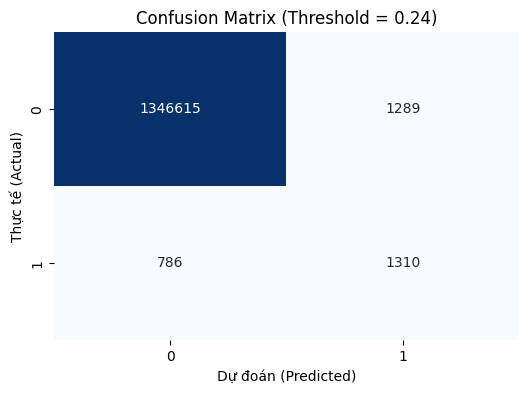

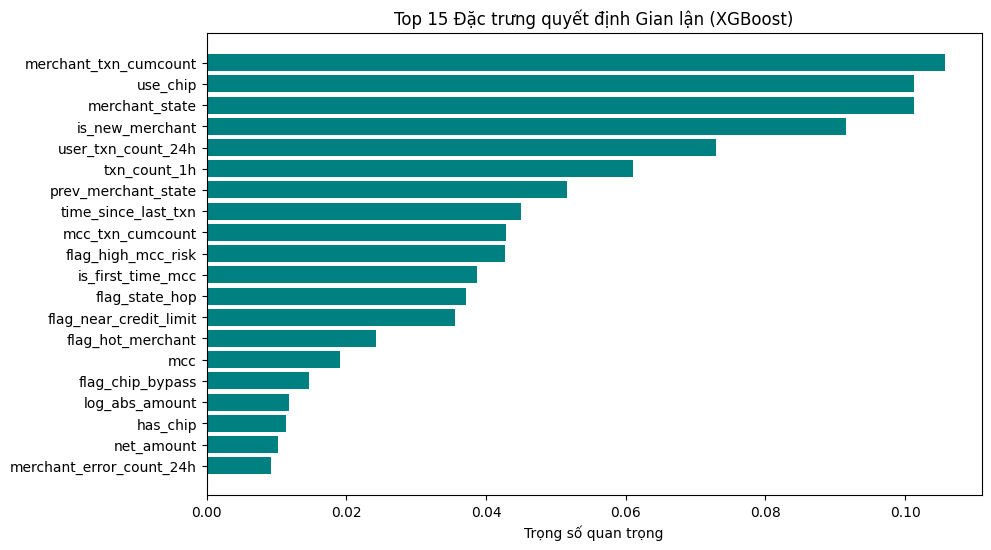

In [7]:
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def step4_evaluate(model, X_train, X_test, y_train, y_test):
    print("\n--- BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH ---")

    # 1. Dự đoán xác suất cho cả 3 tập
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]  # Thêm dự đoán tập Val
    y_test_proba = model.predict_proba(X_test)[:, 1]

# 2. TÌM NGƯỠNG TRÊN TẬP VALIDATION (QUAN TRỌNG)
    p_val, r_val, thresholds_val = precision_recall_curve(y_val, y_val_proba)
    f1_scores_val = 2 * (p_val * r_val) / (p_val + r_val + 1e-10)
    optimal_idx = np.argmax(f1_scores_val)
    optimal_threshold = thresholds_val[optimal_idx] if optimal_idx < len(thresholds_val) else 0.5

    print(f"\n=> Ngưỡng cảnh báo tối ưu (Tìm từ tập Validation): {optimal_threshold:.4f}")

# 3. ĐÁNH GIÁ TRÊN TẬP TEST BẰNG NGƯỠNG ĐÃ TÌM ĐƯỢC
    p_test, r_test, _ = precision_recall_curve(y_test, y_test_proba)
    pr_auc_test = auc(r_test, p_test)
    print(f" -> [ĐIỂM SỐ] PR-AUC (Tập Test) : {pr_auc_test:.4f}")

    y_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)

# Báo cáo phân loại
    print("\nBÁO CÁO PHÂN LOẠI (TRÊN TẬP TEST ĐỘC LẬP):")
    print(classification_report(y_test, y_pred_optimal))

    # 5. Vẽ Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_optimal)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')
    plt.show()

    # 6. Trực quan hóa Feature Importance
    # Xử lý an toàn cho Feature Importance (Bóc nhiều lớp)
    try:
        if hasattr(model, 'calibrated_classifiers_'):
            # Lấy estimator bên trong lớp vỏ CalibratedClassifierCV
            inner_model = model.calibrated_classifiers_[0].estimator
            
            # Xử lý trường hợp bị bọc thêm bởi FrozenEstimator (Sklearn >= 1.6)
            if hasattr(inner_model, 'estimator'):
                importance = inner_model.estimator.feature_importances_
            else:
                # Dành cho Sklearn cũ
                importance = inner_model.feature_importances_
        else:
            # Mô hình thuần túy
            importance = model.feature_importances_

        feat_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
        feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(20)

        plt.figure(figsize=(10, 6))
        plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='teal')
        plt.title("Top 15 Đặc trưng quyết định Gian lận (XGBoost)")
        plt.xlabel("Trọng số quan trọng")
        plt.show()
    except Exception as e:
        print(f"\n[Cảnh báo] Không thể vẽ biểu đồ Feature Importance: {e}")

# Chạy Bước 4
step4_evaluate(model_calibrated, X_train, X_test, y_train, y_test)

--- BƯỚC 1: NẠP DỮ LIỆU ĐÃ FEATURE ENGINEERING ---
 -> TỔNG CỘNG nạp vào RAM: 3844768 dòng.

--- BƯỚC 2: CHUẨN BỊ DỮ LIỆU (TRAIN - VALIDATION - TEST) ---
 -> Train (Đã giảm tải): 1,144,768 dòng (Gian lận: 9232 vụ)
 -> Validation (Hiệu chỉnh): 1,350,000 dòng (Gian lận: 1858 vụ)
 -> Test (Đánh giá độc lập): 1,350,000 dòng (Gian lận: 2242 vụ)

--- BƯỚC 3: HUẤN LUYỆN XGBOOST GỐC (CHUẨN BỊ CHO HIỆU CHỈNH TOÁN HỌC) ---
 -> Kích hoạt scale_pos_weight phục vụ huấn luyện tập Train: 123.00
 -> Bắt đầu huấn luyện mô hình với Early Stopping...
[0]	validation_0-aucpr:0.21901	validation_1-aucpr:0.02893
[50]	validation_0-aucpr:0.60669	validation_1-aucpr:0.15150
[100]	validation_0-aucpr:0.73251	validation_1-aucpr:0.23462
[150]	validation_0-aucpr:0.77221	validation_1-aucpr:0.31403
[200]	validation_0-aucpr:0.80240	validation_1-aucpr:0.35559
[250]	validation_0-aucpr:0.81823	validation_1-aucpr:0.38061
[300]	validation_0-aucpr:0.82738	validation_1-aucpr:0.39288
[350]	validation_0-aucpr:0.83631	validation_1

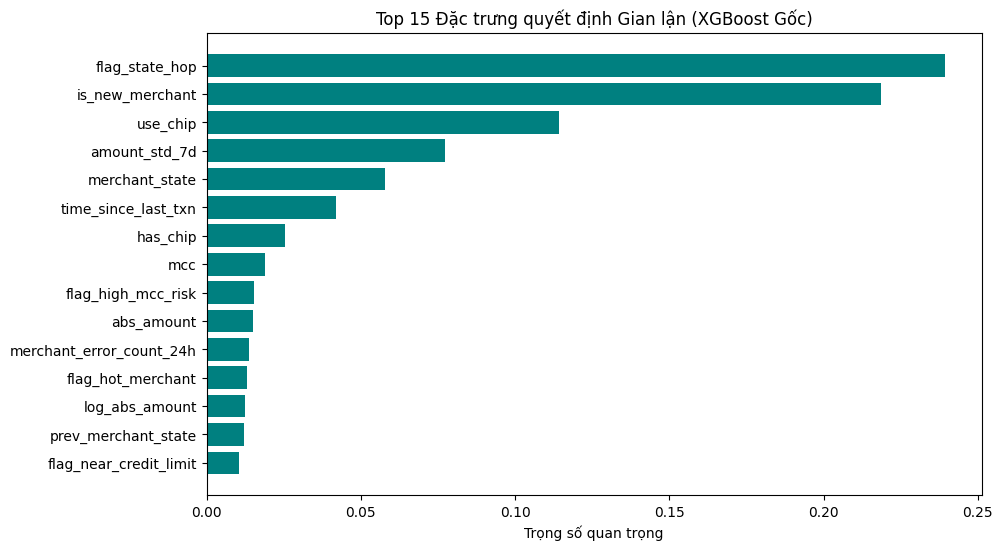

In [11]:
# ========================================================
# HÀM MỚI: HIỆU CHỈNH XÁC SUẤT BẰNG TOÁN HỌC (CỦA BẠN)
# ========================================================
def calibrate_probabilities_math(y_proba, train_ratio, real_ratio):
    """
    Kéo xác suất bị thổi phồng từ tập Train nén về đúng môi trường tỷ lệ thực tế
    Dựa trên định lý Bayes (Prior Correction)
    """
    numerator = y_proba * real_ratio / train_ratio
    denominator = numerator + ((1 - y_proba) * (1 - real_ratio) / (1 - train_ratio))
    return numerator / denominator

# ========================================================
# BƯỚC 3 MỚI: HUẤN LUYỆN XGBOOST THUẦN (KHÔNG PLATT SCALING)
# ========================================================
def step3_train_raw_xgboost(X_train, X_val, y_train, y_val):
    print("\n--- BƯỚC 3: HUẤN LUYỆN XGBOOST GỐC (CHUẨN BỊ CHO HIỆU CHỈNH TOÁN HỌC) ---")
    
    spw = (len(y_train) - sum(y_train)) / (sum(y_train) + 1e-5)
    print(f" -> Kích hoạt scale_pos_weight phục vụ huấn luyện tập Train: {spw:.2f}")
    
    xgb_params = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': 4,
        'min_child_weight': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 5.0,
        'reg_lambda': 5.0,
        'scale_pos_weight': spw,
        'tree_method': 'hist',
        'eval_metric': 'aucpr',
        'early_stopping_rounds': 50,
        'random_state': 42,
        'n_jobs': -1
    }
    
    base_model = xgb.XGBClassifier(**xgb_params)
    print(" -> Bắt đầu huấn luyện mô hình với Early Stopping...")
    base_model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=50
    )
    
    # Không dùng CalibratedClassifierCV nữa, trả về thẳng mô hình gốc
    return base_model

# ========================================================
# BƯỚC 4 MỚI: ĐÁNH GIÁ MÔ HÌNH VỚI XÁC SUẤT HIỆU CHỈNH TOÁN HỌC
# ========================================================
def step4_evaluate_prior_correction(model, X_train, X_test, y_train, y_test):
    print("\n--- BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH (SỬ DỤNG PRIOR CORRECTION) ---")
    
    # 1. Dự đoán xác suất thô (bị thổi phồng do nén dữ liệu)
    y_test_proba_raw = model.predict_proba(X_test)[:, 1]
    y_train_proba_raw = model.predict_proba(X_train)[:, 1]
    
    # 2. Tự động tính tỷ lệ gian lận để đưa vào công thức
    train_ratio = sum(y_train == 1) / len(y_train)  
    real_ratio = sum(y_test == 1) / len(y_test)     
    
    print(f" -> Tỷ lệ mẫu lúc học: {train_ratio:.4f} | Tỷ lệ thực tế: {real_ratio:.5f}")
    
    # 3. ÁP DỤNG CÔNG THỨC TOÁN HỌC HIỆU CHỈNH VỀ THỰC TẾ
    y_test_proba = calibrate_probabilities_math(y_test_proba_raw, train_ratio, real_ratio)
    # Train không cần kéo tỷ lệ, nhưng vẫn cho qua hàm để đồng nhất tham chiếu
    y_train_proba = calibrate_probabilities_math(y_train_proba_raw, train_ratio, train_ratio)
    
    # 4. Tính PR-AUC
    p_test, r_test, thresholds = precision_recall_curve(y_test, y_test_proba)
    pr_auc_test = auc(r_test, p_test)
    
    p_train, r_train, _ = precision_recall_curve(y_train, y_train_proba)
    pr_auc_train = auc(r_train, p_train)
    
    print(f" -> [ĐIỂM THỰC TẾ] PR-AUC (Tập Train): {pr_auc_train:.4f}")
    print(f" -> [ĐIỂM THỰC TẾ] PR-AUC (Tập Test) : {pr_auc_test:.4f}")
    
    # 5. Tìm Ngưỡng tối ưu hóa F1-Score
    f1_scores = 2 * (p_test * r_test) / (p_test + r_test + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
    
    print(f"\n=> Ngưỡng tối ưu bằng Toán học (Optimal Threshold): {optimal_threshold:.4f}")
    
    y_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)
    
    print("\nBÁO CÁO PHÂN LOẠI (PRIOR CORRECTION):")
    print(classification_report(y_test, y_pred_optimal))

    # 6. Trực quan hóa Feature Importance (Mô hình gốc bóc rất dễ)
    try:
        importance = model.feature_importances_
        feat_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
        feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

        plt.figure(figsize=(10, 6))
        plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='teal')
        plt.title("Top 15 Đặc trưng quyết định Gian lận (XGBoost Gốc)")
        plt.xlabel("Trọng số quan trọng")
        plt.show()
    except Exception as e:
        print(f"\n[Cảnh báo] Không thể vẽ biểu đồ Feature Importance: {e}")

# ========================================================
# CẬP NHẬT LẠI HÀM MAIN
# ========================================================
# ========================================================
# CẬP NHẬT LẠI HÀM MAIN
# ========================================================
if __name__ == "__main__":
    DATA_PATH = r"D:\DSS_CK\financial-fraud-dss\data\featured_transactions_data1.csv"
    
    # Bước 1: Nạp file CSV (chỉ trả về 1 biến df_raw)
    df_raw = step1_load_normal(DATA_PATH)
    
    # Bước 2: Chia tập (nhận 1 biến df_raw)
    X_train, X_val, X_test, y_train, y_val, y_test = step2_prepare_data_by_time(df_raw)
    
    # Bước 3: Huấn luyện XGBoost gốc
    model_raw = step3_train_raw_xgboost(X_train, X_val, y_train, y_val)
    
    # Bước 4: Đánh giá bằng công thức Toán học (Prior Correction)
    step4_evaluate_prior_correction(model_raw, X_train, X_test, y_train, y_test)